<a href="https://colab.research.google.com/github/SofiyaPatwekar15/chatgpt-knowledge-base-chatbot/blob/main/NotebooksColab/03_data_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Data Pipeline

Loads `train_ds` / `val_ds` / `test_ds` and `class_weight` via `pipeline_utils`
(shared with `04_baseline_cnn.ipynb`), then verifies them.

## Colab setup — run this first, every session

Colab starts each session with Drive unmounted and cwd = `/content`, so this
cell has to run before anything else, in every notebook, every time you
reconnect. Edit `DRIVE_PROJECT_PATH` once to match where you placed the
project folder in your Drive.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys

DRIVE_PROJECT_PATH = "/content/drive/MyDrive/Fish_freshness_proj"  # <-- EDIT to your path

os.chdir(f"{DRIVE_PROJECT_PATH}/notebooks")
sys.path.append(os.getcwd())   # lets `import config` / `import pipeline_utils` resolve
print("Working directory:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/Fish_freshness_proj/notebooks


In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt

from config import IMG_SIZE
from pipeline_utils import get_datasets, get_class_weight, data_augmentation

print("TF version:", tf.__version__)  # RandomBrightness needs TF >= 2.9

train_ds, val_ds, test_ds = get_datasets()
class_weight = get_class_weight()
print("class_weight:", class_weight)

TF version: 2.20.0
Found 2795 files belonging to 2 classes.
Found 702 files belonging to 2 classes.
Found 878 files belonging to 2 classes.
class_weight: {0: 0.712113532691333, 1: 1.6786140979689366}


## Verification

In [7]:
for x, y in train_ds.take(1):
    print("batch shape:", x.shape, "label shape:", y.shape)
    print("pixel range:", float(x.numpy().min()), float(x.numpy().max()))  # expect ~[0,1]

batch shape: (32, 224, 224, 3) label shape: (32, 1)
pixel range: 0.0 1.0


In [9]:
from config import PROCESSED_DIR
from pathlib import Path

bad = [f for f in PROCESSED_DIR.rglob("*") if f.is_file() and f.stat().st_size == 0]
print(f"{len(bad)} zero-byte files")
print(bad[:10])

0 zero-byte files
[]


Found 2810 files belonging to 2 classes.


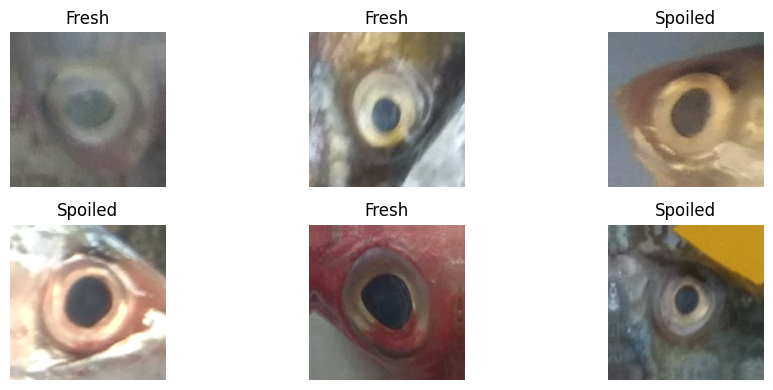

In [10]:
# Visually confirm augmentation looks sane — real fish-eye photos, not
# noise or black frames
raw_batch = next(iter(tf.keras.utils.image_dataset_from_directory(
    "../processed_dataset/train", labels="inferred", label_mode="binary",
    class_names=["Fresh", "Spoiled"], image_size=IMG_SIZE, batch_size=32,
    shuffle=True, seed=1,
)))
x, y = raw_batch
augmented = data_augmentation(x, training=True)
plt.figure(figsize=(10, 4))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented[i].numpy().astype("uint8"))
    plt.title("Spoiled" if y[i] == 1 else "Fresh")
    plt.axis("off")
plt.tight_layout()
plt.show()

---
**Next:** `04_baseline_cnn.ipynb` — small from-scratch CNN, trained with
`class_weight` on `train_ds`/`val_ds`.